# SGKAN Model Results for Different Datasets

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import optuna
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from sgkan import sgkan_model
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def create_export_seed_results(seed_results, name):
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary


In [3]:
def load_dataset(dataset_prefix: str):
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## TF1

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 587, 'interval': 413}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 215, 'interval': 285}
TF1 SGKAN train R2: 0.999999958700483


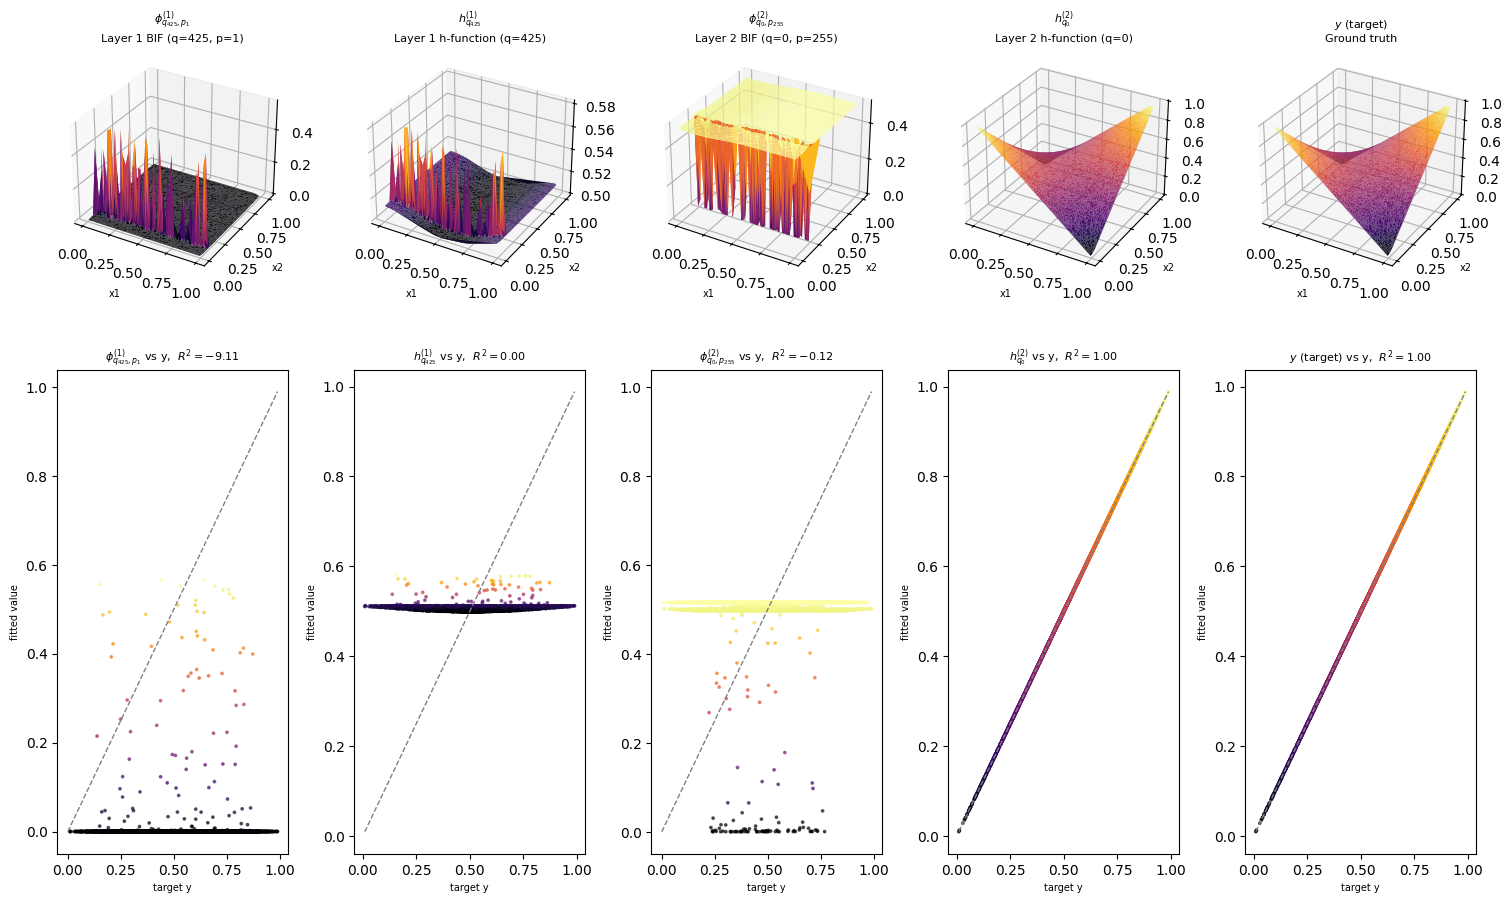

In [4]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 50, "pair_selection_strategy": "swim", "alpha_edge": 1e-1, "alpha_neuron": 1e-6,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]

tf1_sgkan_stages, tf1_sgkan_ytrain_hat, tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, tf1_sgkan_layer_swim_configs)
print("TF1 SGKAN train R2:", r2_score(tf1_y_train, tf1_sgkan_ytrain_hat))

visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_sgkan_stages, block_idx="random", seed=0)
# visualize.plot_first_layer_featurewise_r2_summary_biased(tf1_sgkan_stages, tf1_y_train, tf1_sgkan_layer_neurons)

In [5]:
tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_swim_configs).fit(tf1_x_train, tf1_y_train)

tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 587, 'interval': 413}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 215, 'interval': 285}
[SGKANModel.fit] Total fit duration: 5.1003s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.533454e-05         3.082031e-05        
RMSE            3.380057e-05         5.091420e-05        
-------------------------------------------------------
Inference (s)   3.714751             6.344089            


### Optuna TPE - Parameter Search 

In [6]:
from sgkan import sgkan_parameter_search as sps
import importlib
importlib.reload(sps)

<module 'sgkan.sgkan_parameter_search' from '/Users/gizemnurdal/Workspace/swim-meets-kans/sgkan/sgkan_parameter_search.py'>

In [7]:
tf1_result = sps.study_optuna_sgkan(
    "tf1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    n_trials=625, kernel_type="rbf"
)

[I 2026-07-26 16:18:15,062] A new study created in memory with name: no-name-30265b20-f060-441d-9762-8394bba6e72c


Optimizing SGKAN (layer_width, num_inducing, alpha_edge, alpha_neuron) via GRID on tf1


  0%|          | 0/625 [00:00<?, ?it/s]

[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 256, 'interval': 244}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)


Best trial: 0. Best value: 0.0214774:   0%|          | 1/625 [00:01<18:03,  1.74s/it]

...

[I 2026-07-26 17:29:46,998] Trial 622 finished with value: 0.014909516361757635 and parameters: {'layer_width': 250, 'num_inducing': 100, 'alpha_edge': 0.1, 'alpha_neuron': 10}. Best is trial 389 with value: 1.1401597931601238e-10.
[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=2)
[fit_layer] local-window method counts over 1500 edges: {'interval_capped': 791, 'interval': 709}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval_capped': 594, 'interval': 156}
[SGKANModel.fit] Total fit duration: 8.2226s


Best trial: 389. Best value: 1.14016e-10: 100%|█████████▉| 624/625 [1:11:41<00:08,  8.02s/it]

[I 2026-07-26 17:29:56,381] Trial 623 finished with value: 0.0011422892086258068 and parameters: {'layer_width': 750, 'num_inducing': 50, 'alpha_edge': 0.001, 'alpha_neuron': 0.1}. Best is trial 389 with value: 1.1401597931601238e-10.
[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 256, 'interval': 244}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 87, 'interval_capped': 163}
[SGKANModel.fit] Total fit duration: 4.9679s


Best trial: 389. Best value: 1.14016e-10: 100%|██████████| 625/625 [1:11:47<00:00,  6.89s/it]


[I 2026-07-26 17:30:02,136] Trial 624 finished with value: 0.00632128872897572 and parameters: {'layer_width': 250, 'num_inducing': 100, 'alpha_edge': 10, 'alpha_neuron': 0.1}. Best is trial 389 with value: 1.1401597931601238e-10.

Best trial results:
Best Validation RMSE:   0.000000
Best layer_width:        1000
Best num_inducing:       50
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 795, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 395, 'interval': 605}
[SGKANModel.fit] Total fit duration: 13.0711s
Best Test RMSE:          0.000000

All 625 trials:
     number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron  user_attrs_val_rmse  u

In [8]:
tf1_result

{'layer_width': 1000,
 'num_inducing': 50,
 'alpha_edge': 1,
 'alpha_neuron': 0,
 'kernel_type': 'rbf',
 'sigma_scale': 1,
 'layer_configs': [{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1,
   'alpha_neuron': 0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1,
   'alpha_neuron': 0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 'test_rmse': 5.534627451551515e-08}